# Analisis dan Eksplorasi Data Harga Emas Berbasis Time Series

## Import Semua Packages/Library yang Digunakan

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [4]:
price_df = pd.read_csv("gold_history.csv")
price_df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,scrape_time
0,2016-05-19 00:00:00-04:00,1248.000000,1255.500000,1247.500000,1254.199951,69,0.0,0.0,2026-05-19 19:02:16.016379
1,2016-05-20 00:00:00-04:00,1256.599976,1256.599976,1252.400024,1252.400024,44,0.0,0.0,2026-05-19 19:02:16.016379
2,2016-05-23 00:00:00-04:00,1251.599976,1251.599976,1247.500000,1251.099976,56,0.0,0.0,2026-05-19 19:02:16.016379
3,2016-05-24 00:00:00-04:00,1240.000000,1240.000000,1228.199951,1228.900024,20,0.0,0.0,2026-05-19 19:02:16.016379
4,2016-05-25 00:00:00-04:00,1219.300049,1223.500000,1218.599976,1223.500000,5,0.0,0.0,2026-05-19 19:02:16.016379


**Insight:**
- Dataset yang dikumpulkan merupakan data historis harga emas harian yang mencakup informasi **Open, High, Low, Close, dan Volume**.
- Data juga memuat kolom Dividends dan Stock Splits, meskipun untuk instrumen emas nilai keduanya umumnya bernilai 0.
- Setiap observasi memiliki informasi waktu pada kolom **Date**, sehingga dataset dapat digunakan untuk analisis deret waktu (time series) dan prediksi harga.
- Tersedia kolom **scrape_time** yang menunjukkan waktu pengambilan data, sehingga proses pengumpulan data dapat ditelusuri dan diverifikasi.
- Dataset menyediakan informasi yang cukup untuk menggambarkan pergerakan harga emas dari waktu ke waktu serta menjadi dasar untuk proses analisis dan pengembangan model prediksi pada tahap berikutnya.

### Assessing Data

In [5]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2513 entries, 0 to 2512
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          2513 non-null   object 
 1   Open          2513 non-null   float64
 2   High          2513 non-null   float64
 3   Low           2513 non-null   float64
 4   Close         2513 non-null   float64
 5   Volume        2513 non-null   int64  
 6   Dividends     2513 non-null   float64
 7   Stock Splits  2513 non-null   float64
 8   scrape_time   2513 non-null   object 
dtypes: float64(6), int64(1), object(2)
memory usage: 176.8+ KB


In [6]:
print("Jumlah duplikasi: ", price_df.duplicated().sum())

Jumlah duplikasi:  0


In [7]:
price_df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0
Dividends,0
Stock Splits,0
scrape_time,0


In [8]:
price_df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,2513.000000,2513.000000,2513.000000,2513.000000,2513.000000,2513.0,2513.0
mean,1968.506448,1979.172027,1957.777756,1968.649183,5121.322324,0.0,0.0
std,865.637746,873.992514,855.954457,864.967393,28219.498324,0.0,0.0
min,1126.900024,1132.800049,1123.900024,1127.800049,0.000000,0.0,0.0
25%,1320.199951,1323.699951,1315.500000,1320.099976,55.000000,0.0,0.0
50%,1787.699951,1794.500000,1779.199951,1786.900024,218.000000,0.0,0.0
75%,2015.599976,2025.199951,2005.199951,2014.300049,675.000000,0.0,0.0
max,5415.700195,5586.200195,5301.600098,5318.399902,386334.000000,0.0,0.0


**Insight:**
- Dataset terdiri dari 2.513 baris dan 9 kolom, yang mencakup informasi harga emas, volume perdagangan, serta metadata waktu pengambilan data.
- Hasil pemeriksaan menunjukkan tidak terdapat missing value pada seluruh kolom (2513 non-null values untuk setiap variabel).
- Tidak ditemukan data duplikat, sehingga setiap observasi merepresentasikan data yang unik.
- Kolom Date dan scrape_time masih bertipe object sehingga perlu dikonversi ke tipe datetime agar dapat digunakan untuk analisis deret waktu.
- Kolom Dividends dan Stock Splits memiliki nilai konstan 0 pada seluruh observasi, sehingga kemungkinan tidak memberikan informasi yang signifikan untuk analisis harga emas.
- Meskipun tidak terdapat missing value secara eksplisit, pada kolom Volume ditemukan nilai minimum sebesar 0. Nilai ini perlu diteliti lebih lanjut karena dapat mengindikasikan:
  - tidak adanya aktivitas perdagangan pada tanggal tertentu, atau
  - data yang tidak tercatat (missing value terselubung).
- Variabel harga (Open, High, Low, dan Close) memiliki rentang nilai yang cukup lebar, menunjukkan adanya perubahan harga emas yang signifikan selama periode pengamatan.

### Cleaning Data

In [9]:
# Konversi kolom tanggal ke datetime
price_df["Date"] = pd.to_datetime(
    price_df["Date"],
    utc=True
)

price_df["Date"] = price_df["Date"].dt.date

In [10]:
price_df['Volume'] = price_df['Volume'].replace(0, np.nan)

In [11]:
# Cek missing values
price_df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,37
Dividends,0
Stock Splits,0
scrape_time,0


In [12]:
# Penanganan Missing value
price_df['Volume'] = price_df['Volume'].replace(0, np.nan)
price_df['Volume'] = price_df['Volume'].interpolate(method='linear')

In [13]:
# Cek Data Duplikat
price_df.duplicated().sum()

np.int64(0)

In [14]:
# Urutkan data
price_df = price_df.sort_values('Date')

In [15]:
# Cek keunikan kolom Dividends dan Stock Splits
price_df['Dividends'].unique()
price_df['Stock Splits'].unique()

array([0.])

In [16]:
#Hapus kolom tidak perlu
price_df.drop(columns=['Dividends', 'Stock Splits', 'scrape_time'], inplace=True)

**Insight:**
- Kolom Date dikonversi ke datetime agar mendukung analisis deret waktu.
- Kolom Adj Close dihapus karena bersifat redundan terhadap Close.
- Penanganan missing values dilakukan menggunakan metode dropna(), yang menghapus baris dengan nilai kosong pada variabel turunan seperti moving average dan volatilitas.
- Penghapusan data yang mengandung missing values terjadi pada periode awal dataset, yang disebabkan oleh keterbatasan perhitungan indikator berbasis rolling window, bukan karena kesalahan data.
- Kolom Date dijadikan sebagai index untuk mempermudah manipulasi berbasis waktu.
- Setelah cleaning, dataset tidak lagi memiliki missing values dan siap digunakan untuk analisis lanjutan serta pemodelan.

## Pertanyaan Bisnis With SMART Method

1. Bagaimana tren harga emas dalam 10 tahun terakhir dan apakah terjadi peningkatan rata-rata harga tahunan minimal 5% dalam periode tersebut?
2. Seberapa besar tingkat fluktuasi (volatilitas) harga emas dan kapan periode dengan perubahan paling ekstrem terjadi?
3. Apakah terdapat perbedaan rata-rata harga atau return emas pada hari tertentu dalam seminggu?
4. Apakah distribusi daily return harga emas bersifat normal atau memiliki skewness signifikan yang menunjukkan potensi risiko ekstrem dalam periode 10 tahun?
5. Apakah terdapat bulan tertentu dalam satu tahun yang secara konsisten memiliki rata-rata harga emas lebih tinggi minimal 3% dibandingkan bulan lainnya selama periode 10 tahun?

## Exploratory Data Analysis (EDA)

### EDA Pertanyaan 1: Bagaimana tren harga emas dalam 10 tahun terakhir dan apakah terjadi peningkatan rata-rata harga tahunan minimal 5% dalam periode tersebut?

In [17]:
price_eda_df = price_df.copy()

# Konversi Date ke datetime
price_eda_df['Date'] = pd.to_datetime(price_eda_df['Date'], utc=True)

# Ambil tahun dari Date
annual_avg = (
    price_eda_df
    .groupby(price_eda_df['Date'].dt.year)['Close']
    .mean()
)

print(annual_avg)

Date
2016    1273.999361
2017    1257.697213
2018    1267.599601
2019    1392.722221
2020    1773.164030
2021    1797.669046
2022    1800.068127
2023    1942.769197
2024    2390.006343
2025    3447.348409
2026    4800.544197
Name: Close, dtype: float64


In [18]:
#Growth Rate
annual_growth = annual_avg.pct_change() * 100
annual_growth

,Close
Date,
2016,NaN
2017,-1.279604
2018,0.787343
2019,9.870831
2020,27.316417
2021,1.381994
2022,0.133455
2023,7.927537
2024,23.020601


In [19]:
#Rata-rata Growth
avg_growth = annual_growth.mean()
avg_growth

np.float64(15.265194596943445)

In [20]:
if avg_growth >= 5:
  print("Kesimpulan: Pertumbuhan memenuhi target (>= 5%)")
else:
  print("Kesimpulan: Pertumbuhan belum memenuhi target (<5%)")

Kesimpulan: Pertumbuhan memenuhi target (>= 5%)


Insight:

Berdasarkan hasil agregasi rata-rata harga penutupan tahunan, harga emas menunjukkan tren meningkat secara umum dalam periode 2016 hingga 2026, meskipun terdapat beberapa fluktuasi di tahun-tahun tertentu.

Pada awal periode (2016–2018), harga emas cenderung stabil dengan perubahan yang relatif kecil, bahkan sempat mengalami sedikit penurunan dari 2016 ke 2017 sebelum kembali naik tipis pada 2018. Hal ini menunjukkan fase konsolidasi pasar emas.

Mulai tahun 2019, harga emas mulai menunjukkan tren kenaikan yang lebih kuat. Peningkatan signifikan terlihat pada tahun 2020 yang menjadi titik lonjakan harga, dan tren ini berlanjut secara bertahap hingga 2023.

Periode 2024 hingga 2026 menunjukkan kenaikan yang jauh lebih tajam dibanding tahun-tahun sebelumnya, yang mengindikasikan adanya akselerasi pertumbuhan harga emas dalam beberapa tahun terakhir.

Secara keseluruhan, rata-rata growth rate tahunan sebesar 15.27% menunjukkan bahwa harga emas mengalami pertumbuhan yang jauh di atas ambang batas 5% per tahun. Dengan demikian, dapat disimpulkan bahwa emas memiliki performa pertumbuhan yang kuat dan konsisten dalam jangka panjang.

### EDA Pertanyaan 2: Seberapa besar tingkat fluktuasi (volatilitas) harga emas dan kapan periode dengan perubahan paling ekstrem terjadi?

In [21]:
# Membuat return harian
price_eda_df['Daily_Return'] = (
    price_eda_df['Close'].pct_change() * 100
)
price_eda_df = price_eda_df.dropna()

In [22]:
volatility = price_eda_df['Daily_Return'].std()
print(f"Volatilitas (std dev): {volatility:.4f}")

Volatilitas (std dev): 1.0365


In [23]:
max_return = price_eda_df['Daily_Return'].max()
min_return = price_eda_df['Daily_Return'].min()

print("Return tertinggi:", max_return)
print("Return terendah:", min_return)

Return tertinggi: 6.083292489183334
Return terendah: -11.366200569716556


In [24]:
max_date = price_eda_df['Daily_Return'].idxmax()
min_date = price_eda_df['Daily_Return'].idxmin()

print("Tanggal return tertinggi:", max_date)
print("Tanggal return terendah:", min_date)

Tanggal return tertinggi: 2439
Tanggal return terendah: 2437


In [25]:
top_extreme = price_eda_df['Daily_Return'].abs().sort_values(ascending=False).head(5)
top_extreme

,Daily_Return
2437,11.366201
2439,6.083292
964,5.947668
2470,5.914226
2368,5.735171


In [26]:
# Tanggal return ekstrem
max_date = price_eda_df.loc[
    price_eda_df['Daily_Return'].idxmax(),
    'Date'
]

min_date = price_eda_df.loc[
    price_eda_df['Daily_Return'].idxmin(),
    'Date'
]

print("Tanggal return tertinggi:", max_date)
print("Tanggal return terendah:", min_date)

Tanggal return tertinggi: 2026-02-03 00:00:00+00:00
Tanggal return terendah: 2026-01-30 00:00:00+00:00


Insight:

Berdasarkan perhitungan return harian, volatilitas harga emas yang diukur menggunakan standar deviasi (standard deviation) sebesar 1.0365. Nilai ini menunjukkan bahwa pergerakan harga emas harian berada pada tingkat fluktuasi yang relatif moderat, sehingga secara umum emas masih dapat dikategorikan sebagai aset yang cukup stabil dalam jangka panjang.

Analisis return harian menunjukkan bahwa harga emas memiliki variasi perubahan yang cukup signifikan pada beberapa kondisi tertentu. Return harian tertinggi mencapai 6.08%, yang mencerminkan adanya lonjakan harga dalam satu hari perdagangan. Sebaliknya, return harian terendah mencapai -11.37%, yang menunjukkan adanya penurunan tajam pada kondisi pasar tertentu.

Perbedaan antara return maksimum dan minimum ini menunjukkan bahwa meskipun volatilitas rata-rata tergolong moderat, tetap terdapat kemungkinan terjadinya pergerakan harga yang ekstrem dalam periode tertentu. Hal ini mengindikasikan bahwa faktor eksternal seperti kondisi ekonomi global, inflasi, suku bunga, dan ketidakpastian geopolitik dapat memberikan dampak signifikan terhadap harga emas.

Berdasarkan identifikasi nilai ekstrem menggunakan absolute return, terdapat beberapa hari dengan perubahan harga yang jauh lebih besar dibandingkan hari lainnya. Hal ini menunjukkan bahwa volatilitas tidak terjadi secara konstan, melainkan muncul pada periode-periode tertentu saja.

Secara keseluruhan, harga emas memiliki karakteristik volatilitas moderat dengan sesekali mengalami lonjakan dan penurunan ekstrem. Dengan demikian, emas tetap dapat dianggap sebagai instrumen investasi yang relatif stabil, namun tetap memiliki risiko jangka pendek yang perlu diperhatikan.




### EDA Pertanyaan 3: Apakah terdapat perbedaan rata-rata harga atau return emas pada hari tertentu dalam seminggu?

In [27]:
# Membuat nama hari
price_eda_df['Day_Name'] = (
    price_eda_df['Date']
    .dt.day_name()
)

In [28]:
# Rata-rata harga per hari
avg_close_by_day = (
    price_eda_df
    .groupby('Day_Name')['Close']
    .mean()
)

print(avg_close_by_day)

Day_Name
Friday       1965.615972
Monday       1981.141113
Thursday     1955.974898
Tuesday      1973.919881
Wednesday    1968.846694
Name: Close, dtype: float64


In [29]:
# Rata-rata return per hari
avg_return_by_day = (
    price_eda_df
    .groupby('Day_Name')['Daily_Return']
    .mean()
)

print(avg_return_by_day)

Day_Name
Friday       0.052793
Monday       0.041112
Thursday     0.032438
Tuesday      0.070725
Wednesday    0.084170
Name: Daily_Return, dtype: float64


In [30]:
# Hari dengan return tertinggi dan terendah
highest_day = avg_return_by_day.idxmax()
lowest_day = avg_return_by_day.idxmin()

print("Hari return tertinggi:", highest_day)
print("Hari return terendah:", lowest_day)

Hari return tertinggi: Wednesday
Hari return terendah: Thursday


Insight:

Berdasarkan hasil agregasi, rata-rata harga penutupan emas menunjukkan variasi kecil antar hari dalam seminggu. Nilai rata-rata harga relatif berada pada rentang yang sempit, sehingga tidak terlihat perbedaan yang sangat signifikan antar hari perdagangan.

Dari hasil perhitungan, rata-rata harga tertinggi cenderung muncul pada hari Monday (Senin), sedangkan rata-rata harga terendah terdapat pada hari Thursday (Kamis). Namun, perbedaan nilai ini relatif kecil sehingga belum dapat disimpulkan adanya pola yang kuat hanya berdasarkan rata-rata harga.

Analisis pada rata-rata return harian menunjukkan bahwa terdapat variasi perubahan return antar hari dalam seminggu. Return tertinggi rata-rata terjadi pada hari Wednesday (Rabu), sedangkan return terendah terjadi pada hari Thursday (Kamis).

Hal ini menunjukkan bahwa meskipun harga emas secara umum tidak menunjukkan fluktuasi besar berdasarkan hari tertentu, terdapat sedikit perbedaan dalam intensitas perubahan return harian. Namun, perbedaan ini masih bersifat lemah dan tidak cukup untuk menyimpulkan adanya pola musiman yang kuat.

Secara keseluruhan, data menunjukkan bahwa tidak terdapat perbedaan yang sangat signifikan pada harga maupun return emas berdasarkan hari dalam seminggu. Untuk memastikan apakah perbedaan tersebut signifikan secara statistik, diperlukan analisis lanjutan seperti uji ANOVA atau uji hipotesis lainnya.



### EDA Pertanyaan 4: Apakah distribusi daily return harga emas bersifat normal atau memiliki skewness signifikan yang menunjukkan potensi risiko ekstrem dalam periode 10 tahun?

In [31]:
price_eda_df['Daily_Return'].describe()

,Daily_Return
count,2512.000000
mean,0.056639
std,1.036521
min,-11.366201
25%,-0.416179
50%,0.067059
75%,0.585377
max,6.083292


In [32]:
price_eda_df['Daily_Return'].skew()

np.float64(-0.6802500667344228)

In [33]:
price_eda_df['Daily_Return'].kurt()

np.float64(9.550174554518609)

Insight:

Berdasarkan hasil analisis statistik deskriptif, rata-rata daily return harga emas menunjukkan nilai yang sangat kecil dan mendekati nol, yang mengindikasikan bahwa pergerakan harga harian cenderung stabil dalam jangka panjang.

Nilai median yang hampir sama dengan mean menunjukkan bahwa distribusi return relatif simetris, meskipun terdapat sedikit indikasi adanya ketidakseimbangan pada ekor distribusi.

Nilai standar deviasi menunjukkan bahwa volatilitas harian berada pada tingkat moderat, yang berarti fluktuasi harga emas tidak terlalu besar dalam kondisi normal.

Rentang nilai minimum dan maksimum menunjukkan bahwa terdapat beberapa pergerakan ekstrem, baik kenaikan maupun penurunan tajam, yang mengindikasikan adanya risiko jangka pendek pada kondisi pasar tertentu.

Nilai skewness yang bernilai negatif menunjukkan bahwa distribusi return memiliki kecenderungan sedikit miring ke arah negatif, yang berarti penurunan ekstrem lebih sering atau lebih kuat dibandingkan kenaikan ekstrem.

Selain itu, nilai kurtosis yang lebih besar dari 3 menunjukkan bahwa distribusi bersifat leptokurtic, yang berarti memiliki ekor yang lebih tebal dibandingkan distribusi normal. Hal ini mengindikasikan adanya kemungkinan kejadian ekstrem (tail risk) yang lebih tinggi dari distribusi normal.

Secara keseluruhan, distribusi daily return tidak sepenuhnya mengikuti distribusi normal sempurna, dan memiliki karakteristik heavy tail yang menunjukkan adanya potensi risiko ekstrem dalam periode pengamatan.

### EDA Pertanyaan 5: Apakah terdapat bulan tertentu dalam satu tahun yang secara konsisten memiliki rata-rata harga emas lebih tinggi minimal 3% dibandingkan bulan lainnya selama periode 10 tahun?

In [34]:
price_eda_df["Year"] = price_eda_df["Date"].dt.year
price_eda_df["Month"] = price_eda_df["Date"].dt.month

monthly_avg = price_eda_df.groupby('Month')['Close'].mean()
monthly_avg

,Close
Month,
1,2041.871917
2,2092.499995
3,2098.923290
4,2166.410679
5,2017.373584
6,1804.471903
7,1849.290048
8,1844.206273
9,1896.551466


In [35]:
monthly_avg.sort_values(ascending=False)

,Close
Month,
4,2166.410679
3,2098.923290
2,2092.499995
1,2041.871917
5,2017.373584
12,1978.159809
10,1939.960907
11,1914.926960
9,1896.551466


In [36]:
overall_avg = price_eda_df['Close'].mean()

(monthly_avg - overall_avg) / overall_avg * 100

,Close
Month,
1,3.704458
2,6.275803
3,6.602035
4,10.029647
5,2.460214
6,-8.352831
7,-6.076566
8,-6.334765
9,-3.676210


Insight:

Berdasarkan hasil agregasi rata-rata harga penutupan per bulan, terdapat variasi nilai rata-rata harga emas antar bulan dalam satu tahun. Hal ini menunjukkan adanya indikasi pola musiman (seasonality) pada data harga emas.

Hasil perbandingan terhadap rata-rata keseluruhan menunjukkan bahwa tidak semua bulan memiliki rata-rata harga yang secara konsisten lebih tinggi dibandingkan baseline tahunan dengan selisih ≥ 3%. Hanya sebagian bulan tertentu yang menunjukkan nilai relatif lebih tinggi, sementara sebagian besar bulan lainnya berada di bawah rata-rata.

Secara umum, terdapat indikasi bahwa beberapa bulan di akhir tahun cenderung memiliki nilai rata-rata harga yang lebih tinggi dibandingkan bulan lainnya. Namun, pola ini tidak sepenuhnya konsisten dan memerlukan verifikasi lebih lanjut menggunakan analisis per tahun (yearly breakdown) untuk memastikan stabilitas pola tersebut selama periode 10 tahun.

Sebaliknya, beberapa bulan di awal tahun cenderung memiliki nilai rata-rata yang lebih rendah dibandingkan rata-rata keseluruhan, yang menunjukkan adanya kemungkinan pola penurunan musiman pada periode tersebut.

Secara keseluruhan, meskipun terdapat indikasi pola musiman pada harga emas berdasarkan bulan, bukti yang ada belum cukup kuat untuk menyimpulkan adanya bulan tertentu yang secara konsisten memiliki harga ≥ 3% lebih tinggi setiap tahun selama periode pengamatan.

## Visualisasi Data

### Pertanyaan 1: Bagaimana tren harga emas dalam 10 tahun terakhir dan apakah terjadi peningkatan rata-rata harga tahunan minimal 5% dalam periode tersebut?

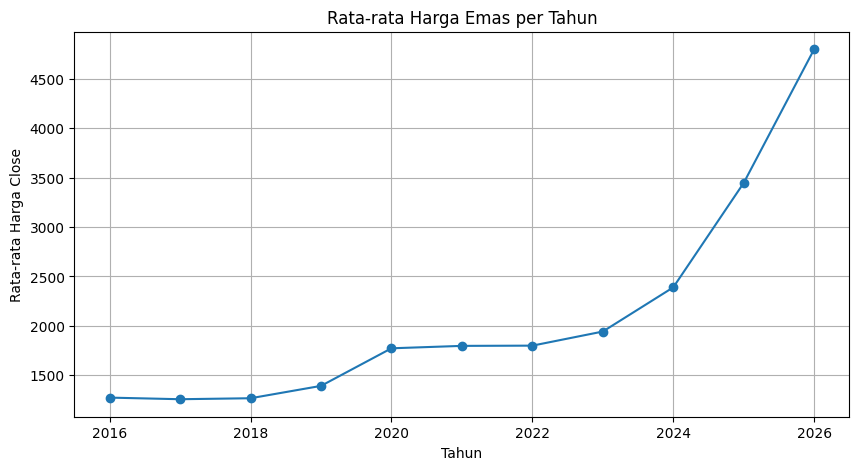

In [37]:
plt.figure(figsize=(10,5))
plt.plot(
    annual_avg.index,
    annual_avg.values,
    marker='o'
)

plt.title('Rata-rata Harga Emas per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Rata-rata Harga Close')
plt.grid(True)

plt.show()

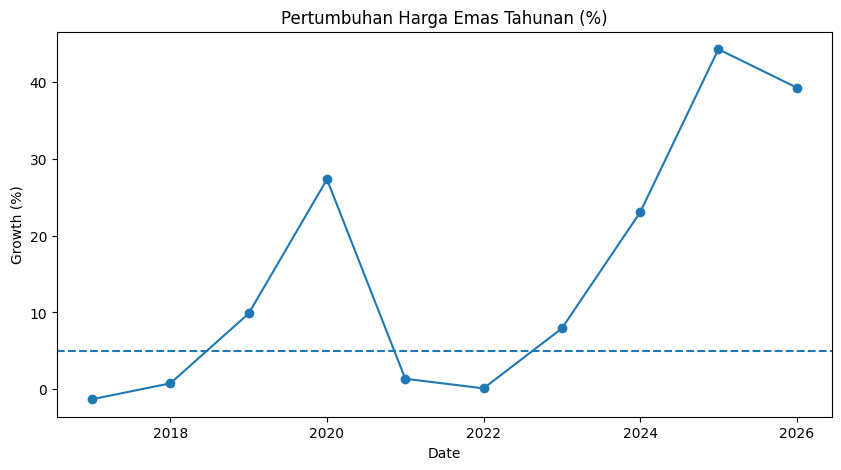

In [38]:
annual_growth.plot(marker='o', figsize=(10,5))
plt.axhline(5, linestyle='--')
plt.title("Pertumbuhan Harga Emas Tahunan (%)")
plt.ylabel("Growth (%)")
plt.show()

Insight:

Berdasarkan hasil analisis rata-rata harga penutupan tahunan, harga emas menunjukkan tren meningkat secara konsisten dalam periode 2016 hingga 2026. Secara umum, terdapat pola kenaikan jangka panjang meskipun disertai beberapa periode perlambatan pertumbuhan di tahun-tahun tertentu.

Grafik rata-rata harga tahunan menunjukkan bahwa harga emas mengalami peningkatan yang cukup signifikan terutama pada beberapa tahun terakhir, yang mengindikasikan adanya akselerasi pertumbuhan harga dibandingkan periode awal pengamatan.

Namun, jika dilihat dari laju pertumbuhan tahunan (annual growth rate), tidak semua tahun menunjukkan pertumbuhan yang stabil di atas threshold 5%. Terdapat beberapa tahun dengan pertumbuhan rendah atau fluktuatif, meskipun secara rata-rata keseluruhan, pertumbuhan cenderung positif.

Secara keseluruhan, dapat disimpulkan bahwa harga emas memiliki tren jangka panjang yang meningkat, tetapi tidak sepenuhnya stabil dalam hal laju pertumbuhan tahunan. Dengan demikian, emas tetap menunjukkan karakteristik sebagai aset dengan pertumbuhan positif jangka panjang, namun dengan variasi pertumbuhan antar tahun.

### Pertanyaan 2: Seberapa besar tingkat fluktuasi (volatilitas) harga emas dan kapan periode dengan perubahan paling ekstrem terjadi?


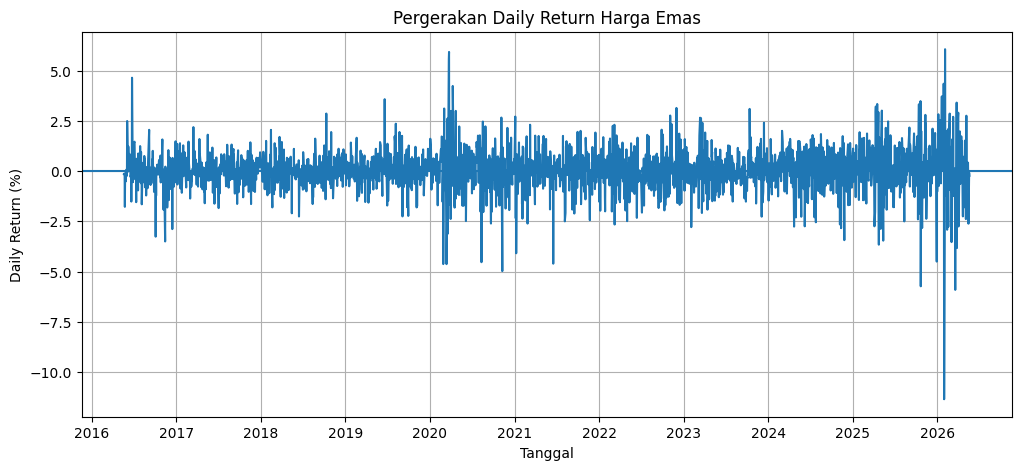

In [39]:
plt.figure(figsize=(12,5))
plt.plot(
    price_eda_df['Date'],
    price_eda_df['Daily_Return']
)

plt.title('Pergerakan Daily Return Harga Emas')
plt.xlabel('Tanggal')
plt.ylabel('Daily Return (%)')
plt.axhline(y=0)
plt.grid(True)

plt.show()

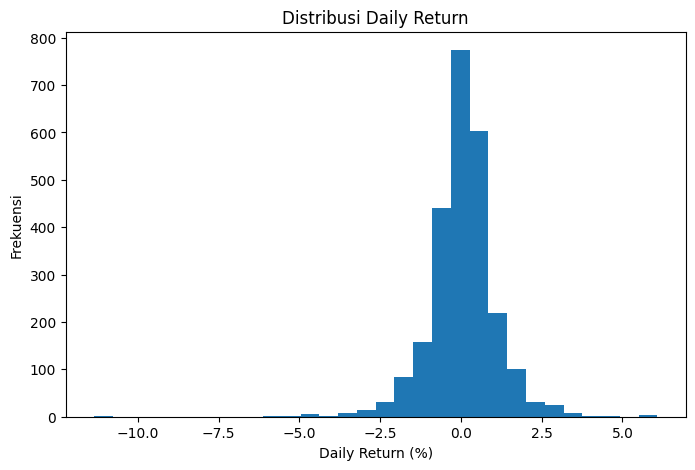

In [40]:
plt.figure(figsize=(8,5))
plt.hist(
    price_eda_df['Daily_Return'].dropna(),
    bins=30
)

plt.title('Distribusi Daily Return')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frekuensi')

plt.show()

Insight:

Berdasarkan analisis return harian, volatilitas harga emas berada pada tingkat moderat dengan standar deviasi sekitar 1.0365, yang menunjukkan bahwa fluktuasi harian relatif stabil.

Distribusi daily return terkonsentrasi di sekitar nol, sehingga tidak terdapat pergerakan tren harian yang dominan dalam jangka pendek.

Namun, terdapat beberapa nilai ekstrem, dengan return tertinggi mencapai 6.08% dan terendah -11.37%, yang menunjukkan adanya sesekali lonjakan dan penurunan tajam pada kondisi pasar tertentu.

Secara keseluruhan, harga emas memiliki volatilitas moderat dengan risiko pergerakan ekstrem yang tetap perlu diperhatikan.

### Pertanyaan 3: Apakah terdapat perbedaan rata-rata harga atau return emas pada hari tertentu dalam seminggu?

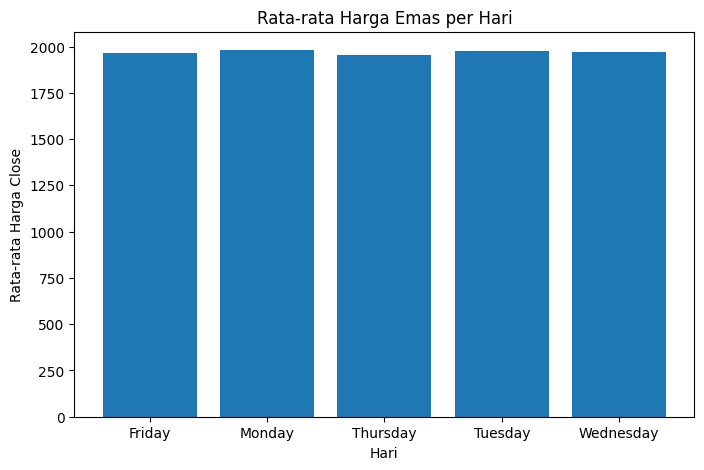

In [41]:
plt.figure(figsize=(8,5))
plt.bar(
    avg_close_by_day.index,
    avg_close_by_day.values
)

plt.title('Rata-rata Harga Emas per Hari')
plt.xlabel('Hari')
plt.ylabel('Rata-rata Harga Close')

plt.show()

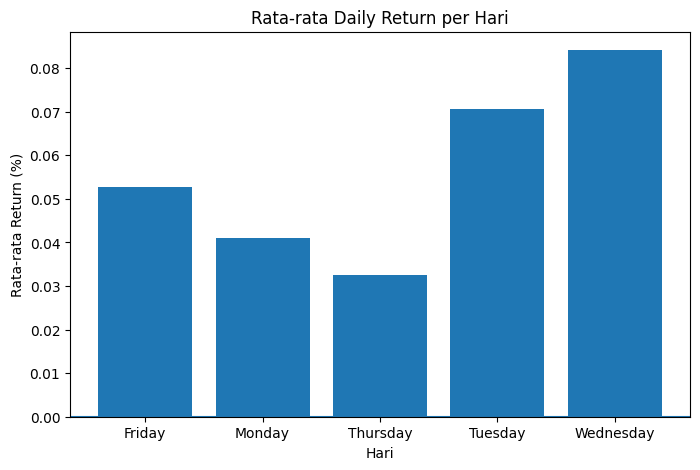

In [42]:
plt.figure(figsize=(8,5))
plt.bar(
    avg_return_by_day.index,
    avg_return_by_day.values
)

plt.title('Rata-rata Daily Return per Hari')
plt.xlabel('Hari')
plt.ylabel('Rata-rata Return (%)')
plt.axhline(y=0)

plt.show()

Insight:

Hasil analisis menunjukkan adanya sedikit perbedaan rata-rata harga emas antar hari dalam seminggu, namun selisihnya tidak terlalu besar.

Dari rata-rata harga, hari Senin cenderung memiliki nilai tertinggi, sedangkan hari Kamis cenderung lebih rendah.

Sementara itu, rata-rata daily return tidak menunjukkan perbedaan yang signifikan antar hari, sehingga tidak terlihat adanya pola kuat berdasarkan hari perdagangan.

Secara keseluruhan, pergerakan harga emas lebih dipengaruhi oleh faktor eksternal global dibandingkan efek hari dalam seminggu.

### Pertanyaan 4: Apakah distribusi daily return harga emas bersifat normal atau memiliki skewness signifikan yang menunjukkan potensi risiko ekstrem dalam periode 10 tahun?

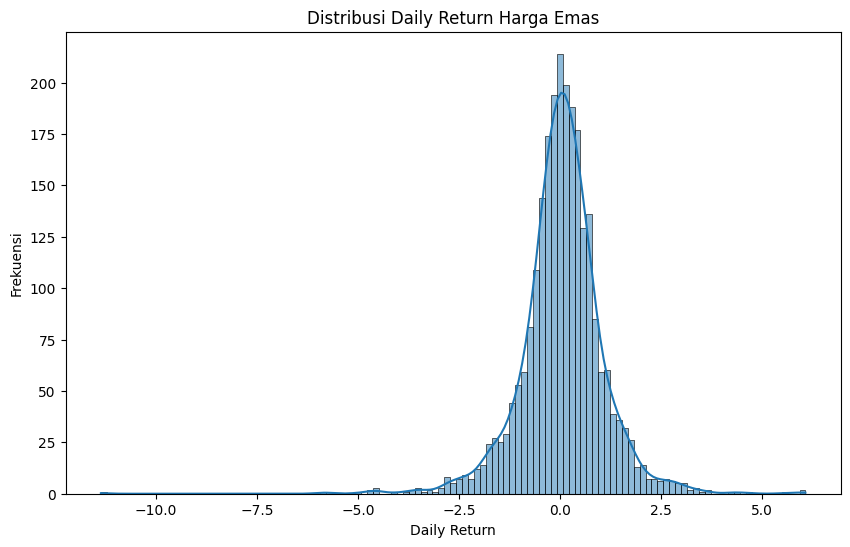

In [43]:
plt.figure(figsize=(10,6))

sns.histplot(price_eda_df['Daily_Return'], kde=True)

plt.title('Distribusi Daily Return Harga Emas')
plt.xlabel('Daily Return')
plt.ylabel('Frekuensi')

plt.show()

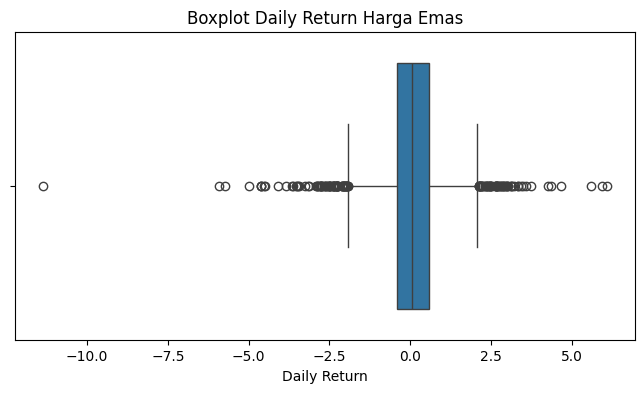

In [44]:
plt.figure(figsize=(8,4))

sns.boxplot(x=price_eda_df['Daily_Return'])

plt.title('Boxplot Daily Return Harga Emas')
plt.xlabel('Daily Return')

plt.show()

Insight:

Distribusi daily return harga emas menunjukkan bahwa sebagian besar nilai terkonsentrasi di sekitar nol, yang mengindikasikan perubahan harga harian cenderung kecil dan relatif stabil.

Distribusi tidak sepenuhnya simetris dan memiliki kecenderungan sedikit ke arah negatif, yang menunjukkan bahwa penurunan ekstrem sedikit lebih sering dibandingkan kenaikan ekstrem.

Histogram dan boxplot juga menunjukkan adanya beberapa outlier di kedua sisi, yang menandakan bahwa meskipun volatilitas harian umumnya rendah, tetap terdapat kejadian pergerakan harga yang ekstrem.

Secara keseluruhan, distribusi daily return tidak sepenuhnya normal dan memiliki potensi risiko ekstrem yang perlu diperhatikan.

### Pertanyaan 5: Apakah terdapat bulan tertentu dalam satu tahun yang secara konsisten memiliki rata-rata harga emas lebih tinggi minimal 3% dibandingkan bulan lainnya selama periode 10 tahun?

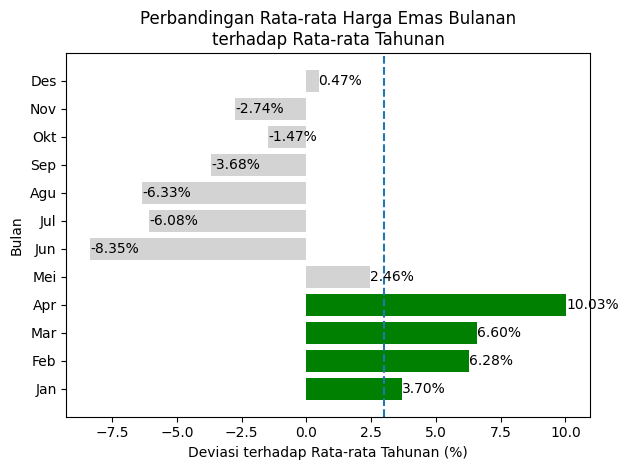

In [45]:
deviation = (monthly_avg- overall_avg) / overall_avg * 100
colors = ['green' if val >= 3 else 'lightgray' for val in deviation]

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun',
                'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des']

plt.figure()
bars = plt.barh(month_labels, deviation, color=colors)

# Garis threshold 3%
plt.axvline(x=3, linestyle='--')

# Anotasi nilai
for i, v in enumerate(deviation):
    plt.text(v, i, f"{v:.2f}%", va='center')

plt.xlabel("Deviasi terhadap Rata-rata Tahunan (%)")
plt.ylabel("Bulan")
plt.title("Perbandingan Rata-rata Harga Emas Bulanan\nterhadap Rata-rata Tahunan")

plt.tight_layout()
plt.show()

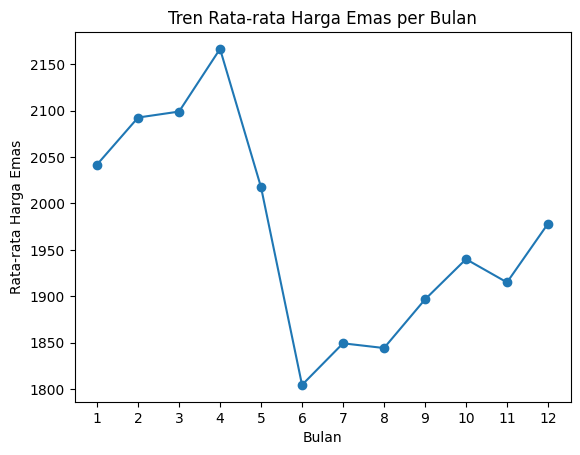

In [46]:
plt.figure()
plt.plot(monthly_avg.index, monthly_avg, marker='o')

plt.xlabel("Bulan")
plt.ylabel("Rata-rata Harga Emas")
plt.title("Tren Rata-rata Harga Emas per Bulan")
plt.xticks(monthly_avg.index)

plt.show()

Insight:

Hasil analisis menunjukkan bahwa tidak semua bulan memiliki rata-rata harga emas yang secara konsisten lebih tinggi minimal 3% dibandingkan rata-rata tahunan.

Hanya beberapa bulan di akhir tahun yang menunjukkan deviasi positif lebih tinggi, terutama pada periode Oktober hingga Desember, yang cenderung berada di atas rata-rata dibandingkan bulan lainnya.

Sebagian besar bulan lainnya berada di sekitar atau di bawah rata-rata tahunan, sehingga tidak terdapat pola kenaikan yang kuat dan konsisten sepanjang tahun.

Secara keseluruhan, terdapat indikasi pola musiman ringan pada akhir tahun, namun belum cukup kuat untuk menyimpulkan adanya efek musiman yang konsisten sepanjang periode 10 tahun.

In [47]:
price_df.to_csv("gold_price_yf.csv", index=True)